In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import io
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import glob
import torch
from torch.utils.data import Dataset

In [3]:
files = glob.glob('./opentouch/data/*.hdf5')
print(f"Found {len(files)} HDF5 files:")
for f in sorted(files):
    print(f"  {f}")

Found 11 HDF5 files:
  ./opentouch/data/hardware_homedepot_p3.hdf5
  ./opentouch/data/hardware_homedepot_p4.hdf5
  ./opentouch/data/hardware_homedepot_p5.hdf5
  ./opentouch/data/home_bedroom.hdf5
  ./opentouch/data/home_kitchen_p1.hdf5
  ./opentouch/data/home_kitchen_p3.hdf5
  ./opentouch/data/office_csail_p1.hdf5
  ./opentouch/data/office_csail_p2.hdf5
  ./opentouch/data/office_ml_p1.hdf5
  ./opentouch/data/office_ml_p2.hdf5
  ./opentouch/data/sports_dicks_p2.hdf5


In [4]:
all_pressure = []

for fpath in sorted(files):
    f = h5py.File(fpath, 'r')
    demos = [k for k in f['data'].keys() if k.startswith('demo')]
    print(f"{fpath}: {len(demos)} demos")
    for d in demos:
        all_pressure.append(f['data'][d]['right_pressure'][:])
    f.close()

all_pressure = np.concatenate(all_pressure, axis=0)
print(f"\nTotal frames across all files: {all_pressure.shape[0]}")

./opentouch/data/hardware_homedepot_p3.hdf5: 135 demos
./opentouch/data/hardware_homedepot_p4.hdf5: 95 demos
./opentouch/data/hardware_homedepot_p5.hdf5: 184 demos
./opentouch/data/home_bedroom.hdf5: 138 demos
./opentouch/data/home_kitchen_p1.hdf5: 190 demos
./opentouch/data/home_kitchen_p3.hdf5: 36 demos
./opentouch/data/office_csail_p1.hdf5: 121 demos
./opentouch/data/office_csail_p2.hdf5: 113 demos
./opentouch/data/office_ml_p1.hdf5: 331 demos
./opentouch/data/office_ml_p2.hdf5: 271 demos
./opentouch/data/sports_dicks_p2.hdf5: 125 demos

Total frames across all files: 171074


In [4]:
all_pressure.shape

(171074, 16, 16)

### Data Analysis

In [7]:
print("\n=== VALUE DISTRIBUTION ===")
flat = all_pressure.flatten()
print(f"Min:    {flat.min():.1f}")
print(f"Max:    {flat.max():.1f}")
print(f"Mean:   {flat.mean():.1f}")
print(f"Median: {np.median(flat):.1f}")
for p in [0.1, 0.5, 1, 25, 50, 75, 90, 95, 99, 99.5, 99.9]:
    print(f"  {p}th percentile: {np.percentile(flat, p):.1f}")


=== VALUE DISTRIBUTION ===
Min:    0.0
Max:    3072.0
Mean:   2906.1
Median: 3052.0
  0.1th percentile: 0.0
  0.5th percentile: 0.0
  1th percentile: 920.0
  25th percentile: 2853.0
  50th percentile: 3052.0
  75th percentile: 3072.0
  90th percentile: 3072.0
  95th percentile: 3072.0
  99th percentile: 3072.0
  99.5th percentile: 3072.0
  99.9th percentile: 3072.0


Fraction exactly zero:    0.006
Fraction exactly at max:  0.446
Fraction in between:      0.548

In-between values: 24009518 total
  min: 1
  max: 3070
  mean: 2802


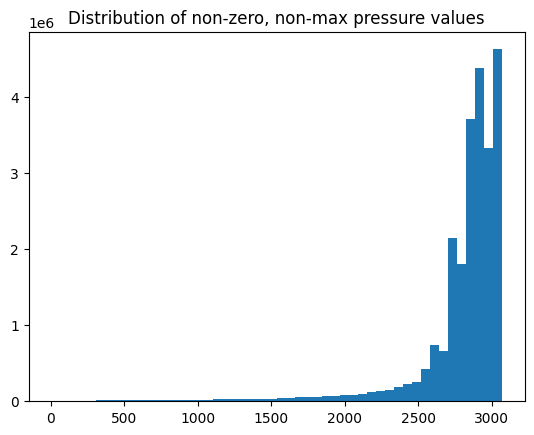

In [8]:
print(f"Fraction exactly zero:    {(all_pressure == 0).mean():.3f}")
print(f"Fraction exactly at max:  {(all_pressure == 3072).mean():.3f}")
print(f"Fraction in between:      {((all_pressure > 0) & (all_pressure < 3072)).mean():.3f}")

# Plot just the in-between values to see if there's any real signal
mid_vals = all_pressure[(all_pressure > 0) & (all_pressure < 3072)]
print(f"\nIn-between values: {len(mid_vals)} total")
if len(mid_vals) > 0:
    print(f"  min: {mid_vals.min():.0f}")
    print(f"  max: {mid_vals.max():.0f}")
    print(f"  mean: {mid_vals.mean():.0f}")
    plt.hist(mid_vals, bins=50)
    plt.title("Distribution of non-zero, non-max pressure values")
    plt.show()

In [6]:
print("=== SATURATION ANALYSIS ===")
print(f"Fraction of values AT max (3072): {(flat == 3072).mean():.4f}")
print(f"Fraction of values > 3000:        {(flat > 3000).mean():.4f}")
print(f"Fraction of values == 0:          {(flat == 0).mean():.4f}")
print(f"Fraction of values between 1-3071 (unsaturated contact): {((flat > 0) & (flat < 3072)).mean():.4f}")

# Per-cell saturation
cell_sat = (all_pressure == 3072).mean(axis=0)
print(f"\nCells saturated >90% of frames: {(cell_sat > 0.9).sum()}")
print(f"Cells saturated >50% of frames: {(cell_sat > 0.5).sum()}")
print(f"Cells NEVER saturated:           {(cell_sat == 0).sum()}")
print(f"Cells always at exactly 0:       {(all_pressure.max(axis=0) == 0).sum()}")

# What does the non-saturated distribution look like?
unsaturated = flat[(flat > 0) & (flat < 3072)]
print(f"\nUnsaturated values (the only informative ones):")
print(f"  Count: {len(unsaturated)} ({len(unsaturated)/len(flat)*100:.1f}% of all values)")
print(f"  Min: {unsaturated.min():.1f}")
print(f"  Max: {unsaturated.max():.1f}")
print(f"  Mean: {unsaturated.mean():.1f}")
for p in [25, 50, 75, 90]:
    print(f"  {p}th percentile: {np.percentile(unsaturated, p):.1f}")

=== SATURATION ANALYSIS ===
Fraction of values AT max (3072): 0.4459
Fraction of values > 3000:        0.5581
Fraction of values == 0:          0.0059
Fraction of values between 1-3071 (unsaturated contact): 0.5482

Cells saturated >90% of frames: 42
Cells saturated >50% of frames: 118
Cells NEVER saturated:           0
Cells always at exactly 0:       0

Unsaturated values (the only informative ones):
  Count: 24009518 (54.8% of all values)
  Min: 1.0
  Max: 3070.0
  Mean: 2802.2
  25th percentile: 2756.0
  50th percentile: 2891.0
  75th percentile: 2993.0
  90th percentile: 3052.0


In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

cell_mean        = all_pressure.mean(axis=0)
cell_sat         = (all_pressure == 3072).mean(axis=0)
cell_zero        = (all_pressure == 0).mean(axis=0)
cell_std         = all_pressure.std(axis=0)
cell_informative = ((all_pressure > 0) & (all_pressure < 3072)).mean(axis=0)

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'Mean pressure per cell',
        'Fraction saturated (=3072)',
        'Fraction at zero',
        'Std per cell (higher = more informative)',
        'Fraction in informative range (1–3071)',
        'Distribution of per-cell means',
    ]
)

# Row 1
fig.add_trace(go.Heatmap(z=cell_mean,        colorscale='Hot',      name='mean'),        row=1, col=1)
fig.add_trace(go.Heatmap(z=cell_sat,         colorscale='RdYlGn',   reversescale=True,   
                          zmin=0, zmax=1,    name='saturated'),                           row=1, col=2)
fig.add_trace(go.Heatmap(z=cell_zero,        colorscale='Blues',    reversescale=True,   
                          zmin=0, zmax=0.05, name='zero'),                                row=1, col=3)

# Row 2
fig.add_trace(go.Heatmap(z=cell_std,         colorscale='Viridis',  name='std'),          row=2, col=1)
fig.add_trace(go.Heatmap(z=cell_informative, colorscale='Plasma',   
                          zmin=0, zmax=1,    name='informative'),                         row=2, col=2)
fig.add_trace(go.Histogram(x=cell_mean.flatten(), nbinsx=50, 
                            marker_color='steelblue', name='mean dist'),                  row=2, col=3)

# Mean line on histogram
fig.add_vline(x=cell_mean.mean(), line_dash='dash', line_color='red',
              annotation_text=f'mean={cell_mean.mean():.0f}',
              annotation_position='top right', row=2, col=3)

fig.update_layout(height=800, width=1200, title_text='Pressure EDA', showlegend=False)
pio.renderers.default = "iframe"   # or "notebook", "jupyterlab"
fig.show()

# Print most/least variable cells
print("Most variable cells (highest std):")
std_flat  = cell_std.flatten()
mean_flat = cell_mean.flatten()
sat_flat  = cell_sat.flatten()
for idx in np.argsort(std_flat)[::-1][:10]:
    r, c = idx // 16, idx % 16
    print(f"  ({r:2d}, {c:2d})  std={std_flat[idx]:.1f}  mean={mean_flat[idx]:.1f}  sat={sat_flat[idx]:.2f}")

print("\nLeast variable cells (lowest std):")
for idx in np.argsort(std_flat)[:10]:
    r, c = idx // 16, idx % 16
    print(f"  ({r:2d}, {c:2d})  std={std_flat[idx]:.1f}  mean={mean_flat[idx]:.1f}  sat={sat_flat[idx]:.2f}")

Most variable cells (highest std):
  (14, 15)  std=1083.7  mean=1649.8  sat=0.04
  ( 3,  9)  std=1044.1  mean=1908.3  sat=0.06
  ( 0,  9)  std=975.0  mean=2519.7  sat=0.01
  (13, 15)  std=951.4  mean=1839.4  sat=0.01
  (15, 15)  std=941.3  mean=2045.2  sat=0.01
  (12, 15)  std=932.3  mean=1546.9  sat=0.01
  ( 0, 10)  std=926.8  mean=2534.3  sat=0.00
  ( 1,  9)  std=879.4  mean=2463.4  sat=0.14
  ( 1, 10)  std=859.5  mean=2629.4  sat=0.65
  ( 4,  9)  std=826.9  mean=2622.5  sat=0.46

Least variable cells (lowest std):
  ( 7,  0)  std=0.1  mean=3072.0  sat=1.00
  (10,  0)  std=0.3  mean=3072.0  sat=1.00
  ( 4,  4)  std=0.5  mean=3072.0  sat=1.00
  ( 9,  0)  std=0.5  mean=3072.0  sat=1.00
  ( 2,  0)  std=0.7  mean=3072.0  sat=1.00
  ( 4,  0)  std=1.3  mean=3071.9  sat=0.82
  ( 6,  0)  std=1.5  mean=3071.9  sat=0.93
  (15,  0)  std=2.5  mean=3072.0  sat=1.00
  ( 3,  0)  std=2.8  mean=3071.5  sat=0.69
  ( 5,  0)  std=2.9  mean=3071.7  sat=0.34


### Finding Fintertips

In [ ]:
import json
import numpy as np
import plotly.graph_objects as go

with open('./opentouch/preprocess/scratch/handLayoutNewest_meshid.json', 'r') as f:
    layout = json.load(f)['positions']

# Extract all cells with their coordinates
cells = []
for key, val in layout.items():
    row, col = map(int, key.split('-'))
    x = val['x']
    y = val['y']
    has_mesh = len(val.get('mano_vid', [])) > 0
    cells.append({
        'key': key, 'row': row, 'col': col,
        'x': x, 'y': y, 'has_mesh': has_mesh
    })

# Visualize all cells in their 2D hand layout
live   = [c for c in cells if c['has_mesh']]
dead   = [c for c in cells if not c['has_mesh']]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=[c['x'] for c in dead], y=[-c['y'] for c in dead],
    mode='markers', marker=dict(color='lightgray', size=8, symbol='x'),
    text=[c['key'] for c in dead], name='dead (no mesh)'
))

# Live cells colored by row index
fig.add_trace(go.Scatter(
    x=[c['x'] for c in live], y=[-c['y'] for c in live],
    mode='markers+text',
    marker=dict(
        color=[c['row'] for c in live],
        colorscale='Turbo', size=12,
        colorbar=dict(title='row')
    ),
    text=[c['key'] for c in live],
    textposition='top center',
    textfont=dict(size=7),
    name='live cells'
))

fig.update_layout(
    title='16x16 grid cells in 2D hand layout space',
    xaxis_title='x (hand width)',
    yaxis_title='y (hand height, flipped)',
    height=800, width=600
)
fig.show()

# Print extremal cells — these are fingertips (lowest y = furthest from wrist)
print("Cells with smallest y (fingertip direction):")
live_sorted = sorted(live, key=lambda c: c['y'])
for c in live_sorted[:15]:
    print(f"  {c['key']:6s}  x={c['x']:.1f}  y={c['y']:.1f}")

Cells with smallest y (fingertip direction):
  0-6     x=356.9  y=73.6
  0-7     x=363.7  y=73.6
  1-7     x=363.7  y=81.4
  1-6     x=356.9  y=82.4
  2-6     x=356.9  y=89.2
  2-7     x=363.7  y=89.2
  0-9     x=443.3  y=94.6
  0-10    x=450.1  y=95.6
  0-4     x=290.3  y=101.6
  0-3     x=283.5  y=102.6
  1-9     x=441.3  y=103.4
  1-10    x=449.1  y=104.4
  2-9     x=440.3  y=111.2
  1-4     x=291.3  y=111.4
  1-3     x=285.5  y=112.4


In [9]:
with open('./opentouch/preprocess/scratch/handLayoutNewest_meshid.json', 'r') as f:
    layout = json.load(f)['positions']

cells = []
for key, val in layout.items():
    row, col = map(int, key.split('-'))
    cells.append({
        'key': key, 'row': row, 'col': col,
        'x': val['x'], 'y': val['y'],
        'has_mesh': len(val.get('mano_vid', [])) > 0
    })

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=[c['x'] for c in cells],
    y=[c['y'] for c in cells],
    mode='markers+text',
    marker=dict(
        color=[c['row'] for c in cells],
        colorscale='Turbo', size=14,
        colorbar=dict(title='row index')
    ),
    text=[c['key'] for c in cells],
    textposition='top center',
    textfont=dict(size=7),
))

fig.update_layout(
    title='16x16 grid cells — raw x,y from JSON (no flipping)',
    height=700, width=500,
    yaxis=dict(autorange='reversed')  # try with this, then remove it to see both orientations
)
pio.renderers.default = "iframe"   # or "notebook", "jupyterlab"
fig.show()

In [10]:
import numpy as np
import plotly.graph_objects as go
import json
import plotly.io as pio

with open('./opentouch/preprocess/scratch/handLayoutNewest_meshid.json', 'r') as f:
    layout = json.load(f)['positions']

cells = []
for key, val in layout.items():
    row, col = map(int, key.split('-'))
    vals = all_pressure[:, row, col]
    cells.append({
        'key': key, 'row': row, 'col': col,
        'x': val['x'], 'y': val['y'],
        'has_mesh': len(val.get('mano_vid', [])) > 0,
        'mean': vals.mean(),
        'std': vals.std(),
        'max': vals.max(),
        'nonzero': (vals > 0).mean() * 100,
    })

hover_text = [
    f"<b>{c['key']}</b><br>"
    f"mean: {c['mean']:.0f}<br>"
    f"std: {c['std']:.0f}<br>"
    f"max: {c['max']:.0f}<br>"
    f"nonzero: {c['nonzero']:.1f}%"
    for c in cells
]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=[c['x'] for c in cells],
    y=[c['y'] for c in cells],
    mode='markers+text',
    marker=dict(
        color=[c['row'] for c in cells],
        colorscale='Turbo', size=14,
        colorbar=dict(title='row index')
    ),
    text=[c['key'] for c in cells],
    textposition='top center',
    textfont=dict(size=7),
    hovertext=hover_text,
    hoverinfo='text',
))

fig.update_layout(
    title='16x16 grid cells — raw x,y from JSON',
    height=700, width=700,
    yaxis=dict(autorange='reversed'),
    xaxis=dict(range=[150, 620]),
)

pio.renderers.default = "iframe"
fig.show()

### Constructing Dataset

In [11]:
FINGERTIP_CELLS = [
    (13, 14),   # thumb tip
    (13, 15),   # thumb tip
    (14, 13),   # thumb tip
    (0, 10),   # index tip
    (0, 11),   # index tip
    (0, 6),   # middle tip
    (1, 6),   # middle tip
    (0, 5),   # ring tip
    (1, 5),   # ring tip
    (0, 1),  # pinky tip
    (1, 1),  # pinky tip
]

In [12]:
print("Fingertip cell statistics:")
for (r, c) in FINGERTIP_CELLS:
    vals = all_pressure[:, r, c]
    print(f"  ({r},{c})  mean={vals.mean():.0f}  std={vals.std():.0f}  "
          f"  max={vals.max():.0f}  nonzero={( vals > 0).mean():.2%}")

Fingertip cell statistics:
  (13,14)  mean=2551  std=786    max=3072  nonzero=96.77%
  (13,15)  mean=1839  std=951    max=3072  nonzero=86.14%
  (14,13)  mean=2874  std=488    max=3072  nonzero=99.60%
  (0,10)  mean=2534  std=927    max=3072  nonzero=92.53%
  (0,11)  mean=2854  std=133    max=3072  nonzero=100.00%
  (0,6)  mean=2900  std=397    max=3072  nonzero=99.80%
  (1,6)  mean=2746  std=663    max=3072  nonzero=98.06%
  (0,5)  mean=2879  std=172    max=3072  nonzero=100.00%
  (1,5)  mean=2921  std=152    max=3072  nonzero=100.00%
  (0,1)  mean=3021  std=200    max=3072  nonzero=99.82%
  (1,1)  mean=3009  std=335    max=3072  nonzero=99.44%
